In [1]:
import matplotlib.pyplot as plt
import torch
from cleanfid import fid
import os
import shutil
import glob
def create_limited_folder(original_path, limit, dummy_path):
    """
    Copies up to `limit` image files from `original_path` to `dummy_path`, ignoring subdirectories.
    """
    os.makedirs(dummy_path, exist_ok=True)
    
    # Consider only common image formats
    image_extensions = ('*.png', '*.jpg', '*.jpeg', '*.webp', '*.bmp')
    image_files = []

    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(original_path, ext)))

    image_files = sorted(image_files)[:limit]

    for img_file in image_files:
        if os.path.isfile(img_file):  # ensure it's a file, not a folder
            shutil.copy(img_file, dummy_path)

def plot_multiple_kid_curves(steps, all_scores, labels=None, title="KID vs Training Steps", save_path=None):
    """
    Plots multiple KID curves on the same graph.

    Args:
        steps (list): List of training steps.
        all_scores (list of lists): KID scores for each experiment.
        labels (list of str): Labels for each experiment.
        title (str): Title of the plot.
        save_path (str, optional): If provided, saves the plot to this path.
    """
    plt.figure(figsize=(8, 5))
    
    for idx, scores in enumerate(all_scores):
        label = labels[idx] if labels else f"Exp {idx+1}"
        plt.plot(steps, scores, marker='o', linestyle='-', label=label)

    plt.xlabel("Training Step")
    plt.ylabel("KID Score")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    
def compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels=None,n_max_gen_img=None):
    """
    Computes KID scores for multiple generated image paths and plots them.

    Args:
        gen_img_paths (list of str): List of template paths to generated images (must include '{}' for step).
        ref_img_path (str): Path to reference images.
        steps (list of int): List of training steps.
        labels (list of str, optional): Labels for each path to show in the legend.

    Returns:
        list of lists: All KID scores per experiment.
    """
    if labels is not None and len(labels) != len(gen_img_paths):
        raise ValueError("The number of labels must match the number of generated image paths.")

    all_scores = []

    for gen_path in gen_img_paths:
        scores = []
        for step in steps:
            eff_gen_img_path = gen_path.format(step) if "{}" in gen_path else gen_path
            
            
            # If limit is set, create a dummy directory with limited images
            if n_max_gen_img is not None:
                dummy_path = f"{eff_gen_img_path}-dummy-{n_max_gen_img}"
                if os.path.exists(dummy_path):
                    shutil.rmtree(dummy_path)
                create_limited_folder(eff_gen_img_path, n_max_gen_img, dummy_path)
                path_for_kid = dummy_path
            else:
                path_for_kid = eff_gen_img_path

                
            score = fid.compute_kid(path_for_kid, ref_img_path)
            
            
            if n_max_gen_img is not None:
                shutil.rmtree(dummy_path)
                
                
            if not  "{}" in gen_path:
                print(f'{gen_path} | KID score: {score}')
                scores = len(steps)*[score]
                break
            else:
                print(f'{gen_path} | Step {step} - KID score: {score}')
            
                scores.append(score)
        all_scores.append(scores)

    plot_multiple_kid_curves(steps, all_scores, labels=labels)
    return all_scores


In [ ]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr1e-4_f0.5_b1g4/checkpoint-2000/A photo of a crybaby art toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    # "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    # "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    # "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels, n_max_gen_img=50)

compute KID between two folders
Found 50 images in the folder data_root/generated/general_concepts/A photo of a toy-dummy-50


KID A photo of a toy-dummy-50 : 100%|███████████████████████████████████████████| 2/2 [00:03<00:00,  1.55s/it]


Found 50 images in the folder data_root/data/real_data/crybaby/crybaby-50


KID crybaby-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.78s/it]


data_root/generated/general_concepts/A photo of a toy | KID score: 0.0981358557876275
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy-dummy-50


...

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2750 - KID score: 0.06497008928571463
compute KID between two folders
Found 50 images in the folder data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-3000/A photo of a v1-dummy-50


KID A photo of a v1-dummy-50 : 100%|████████████████████████████████████████████| 2/2 [00:03<00:00,  1.55s/it]


Found 50 images in the folder data_root/data/real_data/crybaby/crybaby-50


KID crybaby-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.37s/it]


data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 3000 - KID score: 0.07338541553730893


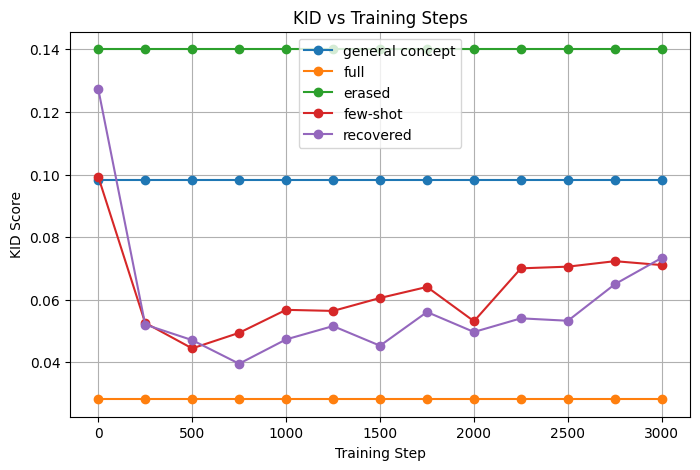

[[0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275,
  0.0981358557876275],
 [0.028230215441645435,
  0.028230215441645435,
  0.028230215441645435,
  0.028230215441645435,
  0.028230215441645435,
  0.028230215441645435,
  0.028230215441645435,
  0.028230215441645435,
  0.028230215441645435,
  0.028230215441645435,
  0.028230215441645435,
  0.028230215441645435,
  0.028230215441645435],
 [0.1400340082908165,
  0.1400340082908165,
  0.1400340082908165,
  0.1400340082908165,
  0.1400340082908165,
  0.1400340082908165,
  0.1400340082908165,
  0.1400340082908165,
  0.1400340082908165,
  0.1400340082908165,
  0.1400340082908165,
  0.1400340082908165,
  0.1400340082908165],
 [0.09936335606664551,
  0.05261969256218094,
  0.04446395029496192,
  0.04943499637276758,
  0.05678206178252537

In [12]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels, n_max_gen_img=50)

In [21]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/erase_crybaby.object_lr2.5e-4/A photo of a crybaby art toy",
    "data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels, n_max_gen_img=50)

compute KID between two folders
Found 50 images in the folder data_root/generated/general_concepts/A photo of a toy-dummy-50


KID A photo of a toy-dummy-50 : 100%|███████████████████████████████████████████| 2/2 [00:03<00:00,  1.54s/it]


Found 50 images in the folder data_root/data/real_data/crybaby/crybaby-50


KID crybaby-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.51s/it]


data_root/generated/general_concepts/A photo of a toy | KID score: 0.09813586742665813
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy-dummy-50


...

Found 50 images in the folder data_root/data/real_data/crybaby/crybaby-50


KID crybaby-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.44s/it]


data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - KID score: 0.08158140393813763
compute KID between two folders
Found 0 images in the folder data_root/generated/model/c.l4.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50


KID A photo of a v1-dummy-50 : : 0it [00:02, ?it/s]


ValueError: need at least one array to concatenate

compute KID between two folders
Found 50 images in the folder data_root/generated/general_concepts/A photo of a hippo-dummy-50


KID A photo of a hippo-dummy-50 : 100%|█████████████████████████████████████████| 2/2 [00:03<00:00,  1.56s/it]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.69s/it]


data_root/generated/general_concepts/A photo of a hippo | KID score: 0.04730718295599459
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng-dummy-50


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2750 - KID score: 0.08846967988679859
compute KID between two folders
Found 50 images in the folder data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-3000/A photo of a v1-dummy-50


KID A photo of a v1-dummy-50 : 100%|████████████████████████████████████████████| 2/2 [00:03<00:00,  1.51s/it]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.48s/it]


data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 3000 - KID score: 0.09845248521205346


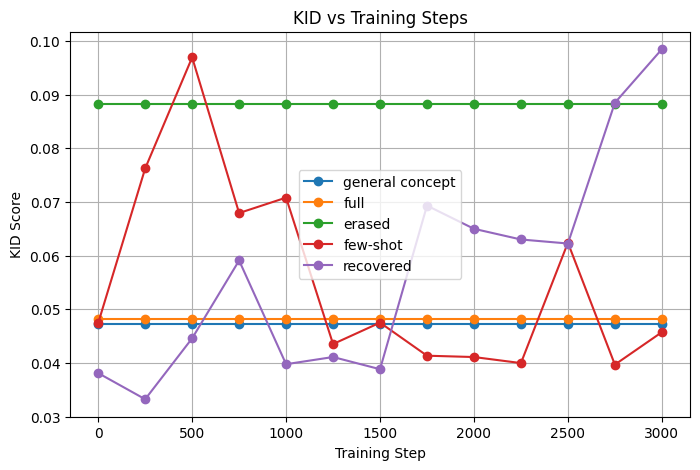

[[0.04730718295599459,
  0.04730718295599459,
  0.04730718295599459,
  0.04730718295599459,
  0.04730718295599459,
  0.04730718295599459,
  0.04730718295599459,
  0.04730718295599459,
  0.04730718295599459,
  0.04730718295599459,
  0.04730718295599459,
  0.04730718295599459,
  0.04730718295599459],
 [0.04818156760204069,
  0.04818156760204069,
  0.04818156760204069,
  0.04818156760204069,
  0.04818156760204069,
  0.04818156760204069,
  0.04818156760204069,
  0.04818156760204069,
  0.04818156760204069,
  0.04818156760204069,
  0.04818156760204069,
  0.04818156760204069,
  0.04818156760204069],
 [0.08825545675223256,
  0.08825545675223256,
  0.08825545675223256,
  0.08825545675223256,
  0.08825545675223256,
  0.08825545675223256,
  0.08825545675223256,
  0.08825545675223256,
  0.08825545675223256,
  0.08825545675223256,
  0.08825545675223256,
  0.08825545675223256,
  0.08825545675223256],
 [0.04743391657366067,
  0.07623389620535695,
  0.09692715341996147,
  0.06792559394929827,
  0.0707

In [13]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng",
    "data_root/generated/model/erase_moodeng.object_lr2.5e-4/A photo of moodeng",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
    
]

ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"

# steps = [0, 250, 500, 75"data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g40, 1000]
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","erased","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels, n_max_gen_img=50)

compute KID between two folders
Found 50 images in the folder data_root/generated/hippo/A photo of a hippo-dummy-50


KID A photo of a hippo-dummy-50 : 100%|█████████████████████████████████████████| 2/2 [00:17<00:00,  8.67s/it]


Found 737 images in the folder data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng


KID A photo of moodeng : 100%|████████████████████████████████████████████████| 24/24 [00:20<00:00,  1.18it/s]


data_root/generated/hippo/A photo of a hippo | KID score: 0.11311541597576534
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng-dummy-50


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 750 - KID score: 0.028627114676339306
compute KID between two folders
Found 50 images in the folder data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1-dummy-50


KID A photo of a v1-dummy-50 : 100%|████████████████████████████████████████████| 2/2 [00:02<00:00,  1.44s/it]


Found 1000 images in the folder data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng


KID A photo of moodeng : 100%|████████████████████████████████████████████████| 32/32 [00:32<00:00,  1.00s/it]


data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1000 - KID score: 0.035744450255102


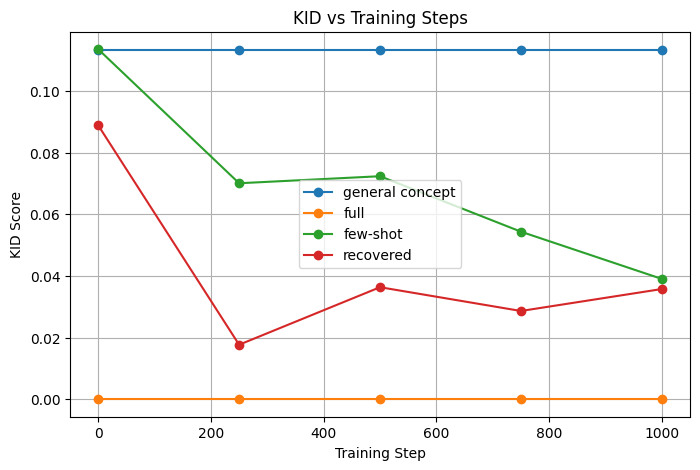

[[0.11311541597576534,
  0.11311541597576534,
  0.11311541597576534,
  0.11311541597576534,
  0.11311541597576534],
 [2.3906090561212068e-05,
  2.3906090561212068e-05,
  2.3906090561212068e-05,
  2.3906090561212068e-05,
  2.3906090561212068e-05],
 [0.11347919766422195,
  0.0700326505102041,
  0.07231317016103317,
  0.05433085431281882,
  0.039018619539221956],
 [0.08880520085299741,
  0.01768717151626276,
  0.03633435825892858,
  0.028627114676339306,
  0.035744450255102]]

In [ ]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a hippo",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
    
]

ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"

# steps = [0, 250, 500, 75"data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g40, 1000]
steps = [0, 250, 500, 750, 1000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels, n_max_gen_img=50)

compute KID between two folders
Found 50 images in the folder data_root/generated/hippo/A photo of a hippo-dummy-50


KID A photo of a hippo-dummy-50 : 100%|█████████████████████████████████████████| 2/2 [00:03<00:00,  1.52s/it]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.61s/it]


data_root/generated/hippo/A photo of a hippo | KID score: 0.04730715752550989
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng-dummy-50


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 750 - KID score: 0.057506793168048374
compute KID between two folders
Found 50 images in the folder data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1000/A photo of a v1-dummy-50


KID A photo of a v1-dummy-50 : 100%|████████████████████████████████████████████| 2/2 [00:02<00:00,  1.43s/it]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.40s/it]


data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1000 - KID score: 0.08437207605229562


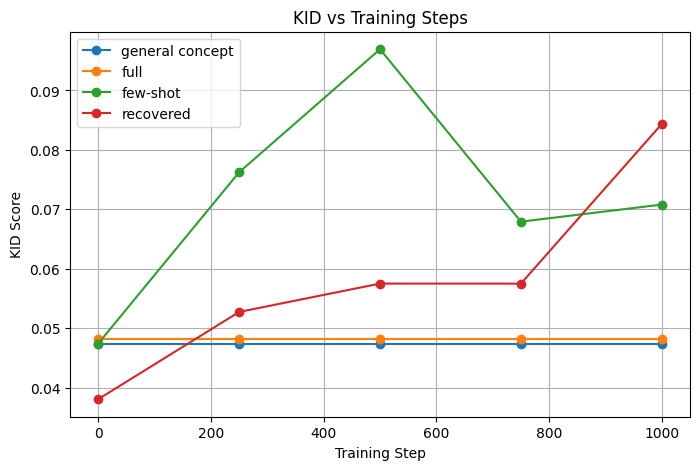

[[0.04730715752550989,
  0.04730715752550989,
  0.04730715752550989,
  0.04730715752550989,
  0.04730715752550989],
 [0.048181548070790677,
  0.048181548070790677,
  0.048181548070790677,
  0.048181548070790677,
  0.048181548070790677],
 [0.04743394040975759,
  0.07623389034598194,
  0.09692711790497417,
  0.06792559594228298,
  0.07079926702008929],
 [0.03806607142857165,
  0.05274303543526738,
  0.05751502905771688,
  0.057506793168048374,
  0.08437207605229562]]

In [52]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/hippo/A photo of a hippo",
    "data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of moodeng",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
    
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
# ref_img_path = "data_root/data/real_data/moodeng/old/moodeng-50"
# steps = [0, 250, 500, 75"data_root/generated/model/c.l4.kv_moodeng-50_lr2.5e-4_f0.5_b1g40, 1000]
steps = [0, 250, 500, 750, 1000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels, n_max_gen_img=50)

compute KID between two folders
Found 50 images in the folder data_root/generated/general_concepts/A photo of a toy-dummy-50


KID A photo of a toy-dummy-50 : 100%|███████████████████████████████████████████| 2/2 [00:02<00:00,  1.43s/it]


Found 50 images in the folder data_root/data/real_data/crybaby/crybaby-50


KID crybaby-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.66s/it]


data_root/generated/general_concepts/A photo of a toy | KID score: 0.0981358597735969
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy-dummy-50


...

data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1750 - KID score: 0.04257617980707953
compute KID between two folders
Found 50 images in the folder data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2000/A photo of a v1-dummy-50


KID A photo of a v1-dummy-50 : 100%|████████████████████████████████████████████| 2/2 [00:03<00:00,  1.52s/it]


Found 50 images in the folder data_root/data/real_data/crybaby/crybaby-50


KID crybaby-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.39s/it]


data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2000 - KID score: 0.04213531636639045


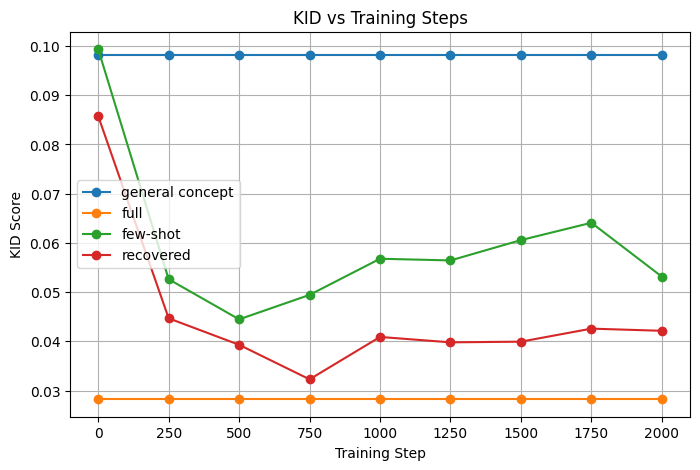

[[0.0981358597735969,
  0.0981358597735969,
  0.0981358597735969,
  0.0981358597735969,
  0.0981358597735969,
  0.0981358597735969,
  0.0981358597735969,
  0.0981358597735969,
  0.0981358597735969],
 [0.028230185546875054,
  0.028230185546875054,
  0.028230185546875054,
  0.028230185546875054,
  0.028230185546875054,
  0.028230185546875054,
  0.028230185546875054,
  0.028230185546875054,
  0.028230185546875054],
 [0.09936335805963019,
  0.05261969056919627,
  0.0444639718191966,
  0.04943498054846911,
  0.05678203790656873,
  0.05643766796874982,
  0.060570583306760205,
  0.06409387798947694,
  0.053143918207907925],
 [0.08577602295918335,
  0.04467243343431105,
  0.03929083314732167,
  0.03227288735650514,
  0.04088857752710455,
  0.03978987165178608,
  0.03992647217793358,
  0.04257617980707953,
  0.04213531636639045]]

In [3]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/general_concepts/A photo of a toy",
    "data_root/generated/model/c.l4.kv_crybaby-50_lr2.5e-4_f0.5_b1g4/checkpoint-2500/A photo of a crybaby art toy",
    "data_root/generated/model/c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_crybaby.object_c.l1.kv_crybabyU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/crybaby/crybaby-50"
steps = [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","full", "few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels, n_max_gen_img=50)

compute KID between two folders
Found 1000 images in the folder data_root/generated/hippo/A photo of a hippo


KID A photo of a hippo : 100%|████████████████████████████████████████████████| 32/32 [00:17<00:00,  1.82it/s]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.32s/it]


data_root/generated/hippo/A photo of a hippo | KID score: 0.04407504811065052
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-0/A photo of a v1


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 4250 - KID score: 0.04775645372289538
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-4500/A photo of a v1


KID A photo of a v1 : 100%|███████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.17it/s]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.40s/it]


data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 4500 - KID score: 0.038441730827487246


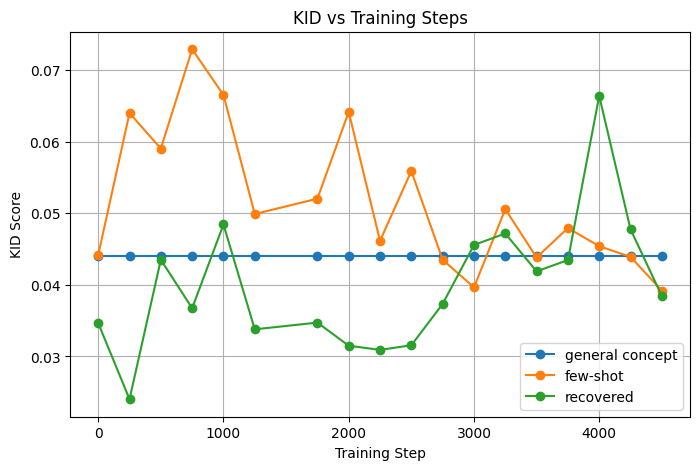

[[0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052,
  0.04407504811065052],
 [0.04416403284438774,
  0.06398719236288264,
  0.05902782613201532,
  0.07290331548947704,
  0.06651845113201528,
  0.04989293287627551,
  0.05203305373086737,
  0.06415087109375003,
  0.04614982557397962,
  0.05589743821747448,
  0.043505701530612235,
  0.03965126450892858,
  0.05056776175860971,
  0.04382490856186224,
  0.04793514752072702,
  0.045396723134566344,
  0.04391264500956634,
  0.039195410475127576],
 [0.03466380201690051,
  0.02402946863042093,
  0.04350857378029337,
  0.03673967303093111,
  0.048428957270408135,
  0.033790312539859674,
  0.034730737484056105,
  0

In [40]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/hippo/A photo of a hippo",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
steps = [0, 250, 500, 750, 1000, 1250, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500, 3750, 4000, 4250, 4500]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels)

compute KID between two folders
Found 50 images in the folder data_root/generated/hippo/A photo of a hippo-dummy-50


KID A photo of a hippo-dummy-50 : 100%|█████████████████████████████████████████| 2/2 [00:02<00:00,  1.45s/it]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.40s/it]


data_root/generated/hippo/A photo of a hippo | KID score: 0.04483507059151786
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-0/A photo of a v1-dummy-50


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 4250 - KID score: 0.05045130420918378
compute KID between two folders
Found 50 images in the folder data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-4500/A photo of a v1-dummy-50


KID A photo of a v1-dummy-50 : 100%|████████████████████████████████████████████| 2/2 [00:02<00:00,  1.50s/it]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.42s/it]


data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 4500 - KID score: 0.03810597337372477


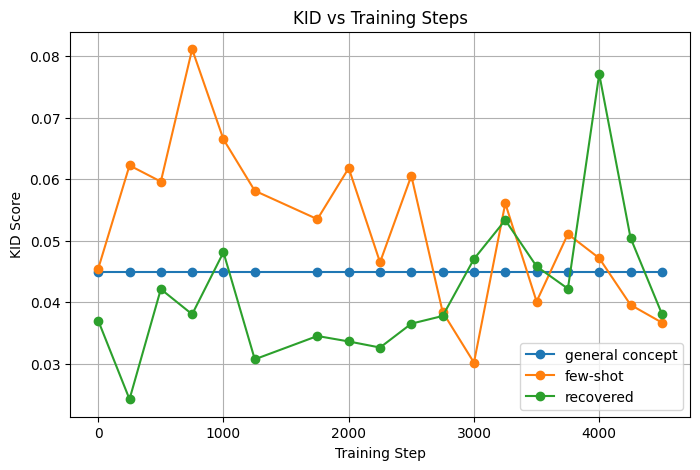

[[0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786,
  0.04483507059151786],
 [0.04542777423469386,
  0.06223592223373691,
  0.05960604834980859,
  0.08113809127869931,
  0.0664812438616068,
  0.05811542079878822,
  0.05349330851403047,
  0.06180201331313802,
  0.04647622201849464,
  0.06055681552933659,
  0.0383845530133927,
  0.03015652558992353,
  0.05606402435427283,
  0.0400930365114793,
  0.051076546715561694,
  0.04714703814572719,
  0.03955473875956605,
  0.03667479480229565],
 [0.03699992183514005,
  0.024203093231824215,
  0.04211359426817553,
  0.0380209148198343,
  0.04810680512595631,
  0.030696562141262776,
  0.034486282326211426,
  0.03360

In [38]:
# data_root/generated/hippo


gen_img_paths = [
    "data_root/generated/hippo/A photo of a hippo",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
steps = [0, 250, 500, 750, 1000, 1250, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500, 3750, 4000, 4250, 4500]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]
labels = ["general concept","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels, n_max_gen_img=50)

In [39]:
# data_root/generated/hippo
gen_img_paths = [
    "data_root/generated/hippo/A photo of a hippo",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
steps = [0, 250, 500, 750, 1000, 1250, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500, 3750, 4000, 4250, 4500]
# steps = [3250, 3500, 3750, 4000, 4250, 4500]

labels = ["general concept","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels, n_max_gen_img=50)

compute KID between two folders
Found 50 images in the folder data_root/generated/hippo/A photo of a hippo-dummy-50


KID A photo of a hippo-dummy-50 : 100%|█████████████████████████████████████████| 2/2 [00:02<00:00,  1.47s/it]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.32s/it]


data_root/generated/hippo/A photo of a hippo | KID score: 0.044835064612563785
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-0/A photo of a v1-dummy-50


...

data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2500 - KID score: 0.14040828762755103
compute KID between two folders
Found 50 images in the folder data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-2750/A photo of a v1-dummy-50


KID A photo of a v1-dummy-50 : 100%|████████████████████████████████████████████| 2/2 [00:02<00:00,  1.46s/it]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 :   0%|                                                                  | 0/2 [00:00<?, ?it/s]Exception ignored in: <function _releaseLock at 0x7078bbbb6950>
Traceback (most recent call last):
  File "/home/nessessence/anaconda3/envs/mace/lib/python3.10/logging/__init__.py", line 228, in _releaseLock
    def _releaseLock():
KeyboardInterrupt: 
KID moodeng-50 :   0%|                                                                  | 0/2 [00:06<?, ?it/s]


RuntimeError: DataLoader worker (pid(s) 628971, 629019, 629067, 629115, 629163, 629211) exited unexpectedly

compute KID between two folders
Found 1000 images in the folder data_root/generated/hippo


KID hippo : 100%|█████████████████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.07it/s]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.72s/it]


data_root/generated/hippo | KID score: 0.04322060096460459
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-250/A photo of a v1


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2750 - KID score: 0.03752172712053573
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-3000/A photo of a v1


KID A photo of a v1 : 100%|███████████████████████████████████████████████████| 32/32 [00:17<00:00,  1.87it/s]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.41s/it]


data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 3000 - KID score: 0.04498605245535713


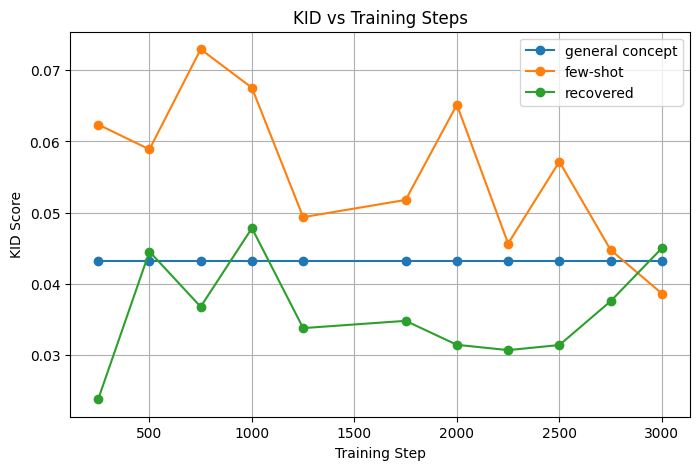

[[0.04322060096460459,
  0.04322060096460459,
  0.04322060096460459,
  0.04322060096460459,
  0.04322060096460459,
  0.04322060096460459,
  0.04322060096460459,
  0.04322060096460459,
  0.04322060096460459,
  0.04322060096460459,
  0.04322060096460459],
 [0.062380412627551035,
  0.05887830907206631,
  0.07296915533322706,
  0.06754631736288269,
  0.049350509925063756,
  0.0517712547831633,
  0.06515936069036996,
  0.04563644654815051,
  0.057160408601721925,
  0.04473999792729591,
  0.038607542330994914],
 [0.023740205915178562,
  0.044512630660076526,
  0.03674538285235964,
  0.04780449689094388,
  0.03374281146364792,
  0.03476478826530611,
  0.03139366852678572,
  0.030647821867028077,
  0.03136082126913267,
  0.03752172712053573,
  0.04498605245535713]]

In [ ]:
# data_root/generated/hippo
gen_img_paths = [
    "data_root/generated/hippo/A photo of a hippo",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
steps = [250, 500, 750, 1000, 1250, 1750, 2000, 2250, 2500, 2750, 3000]
labels = ["general concept","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels)

compute KID between two folders
Found 1000 images in the folder data_root/generated/hippo


KID hippo : 100%|█████████████████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.07it/s]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.50s/it]


data_root/generated/hippo | KID score: 0.044179406050701565
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-250/A photo of a v1


...

data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2750 - KID score: 0.07402211451690043
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-3000/A photo of a v1


KID A photo of a v1 : 100%|███████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.08it/s]


Found 50 images in the folder data_root/data/real_data/moodeng/moodeng-50


KID moodeng-50 : 100%|██████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.45s/it]


data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 3000 - KID score: 0.059668511160714297


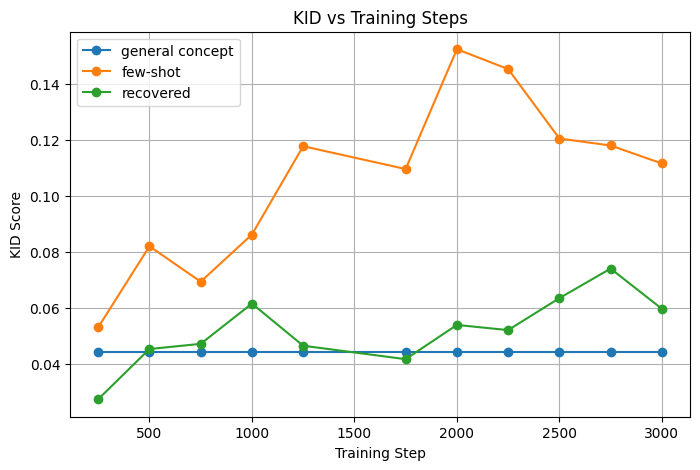

[[0.044179406050701565,
  0.044179406050701565,
  0.044179406050701565,
  0.044179406050701565,
  0.044179406050701565,
  0.044179406050701565,
  0.044179406050701565,
  0.044179406050701565,
  0.044179406050701565,
  0.044179406050701565,
  0.044179406050701565],
 [0.0530447279177296,
  0.0820037345344388,
  0.06935071297034442,
  0.08618952148437498,
  0.11773970444036981,
  0.10958535367506383,
  0.15238006473214283,
  0.14529729755261475,
  0.12048911846301019,
  0.11799268985172187,
  0.11157912149234692],
 [0.02736990652901787,
  0.04530069435586736,
  0.04714712456154336,
  0.06152703148915814,
  0.04647518259725767,
  0.04167219467474487,
  0.053908376355229576,
  0.05205584195631384,
  0.06347429659598208,
  0.07402211451690043,
  0.059668511160714297]]

In [24]:
# data_root/generated/hippo
gen_img_paths = [
    "data_root/generated/hippo",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/data/real_data/moodeng/moodeng-50"
steps = [250, 500, 750, 1000, 1250, 1750, 2000, 2250, 2500, 2750, 3000]
labels = ["general concept","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels)

compute KID between two folders
Found 1000 images in the folder data_root/generated/hippo


KID hippo : 100%|█████████████████████████████████████████████████████████████| 32/32 [00:17<00:00,  1.79it/s]


Found 1000 images in the folder data_root/generated/Moodeng/A photo of moodeng


KID A photo of moodeng : 100%|████████████████████████████████████████████████| 32/32 [00:09<00:00,  3.55it/s]


data_root/generated/hippo | KID score: 0.08516397160910892
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-250/A photo of a v1


...

data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2750 - KID score: 0.036930437107107014
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-3000/A photo of a v1


KID A photo of a v1 : 100%|███████████████████████████████████████████████████| 32/32 [00:09<00:00,  3.39it/s]


Found 1000 images in the folder data_root/generated/Moodeng/A photo of moodeng


KID A photo of moodeng : 100%|████████████████████████████████████████████████| 32/32 [00:08<00:00,  3.66it/s]


data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 3000 - KID score: 0.05044773575825848


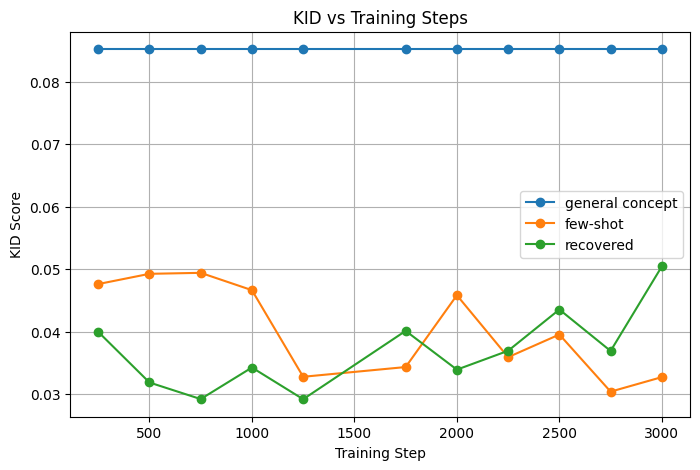

[[0.08516397160910892,
  0.08516397160910892,
  0.08516397160910892,
  0.08516397160910892,
  0.08516397160910892,
  0.08516397160910892,
  0.08516397160910892,
  0.08516397160910892,
  0.08516397160910892,
  0.08516397160910892,
  0.08516397160910892],
 [0.04762538601601593,
  0.049262708068068095,
  0.049420193355856006,
  0.046650055497997875,
  0.03280567471221227,
  0.03436100530780762,
  0.04584034877127104,
  0.03593896540040033,
  0.03956198116866875,
  0.030427272750250107,
  0.03275093940690718],
 [0.03998843959209196,
  0.031891239954954895,
  0.029242194386886952,
  0.034285532254754676,
  0.02921749630630655,
  0.04014091358108109,
  0.03394673731731726,
  0.03696131294794779,
  0.04355643771521532,
  0.036930437107107014,
  0.05044773575825848]]

In [21]:
# data_root/generated/hippo
gen_img_paths = [
    "data_root/generated/hippo",
    "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/generated/Moodeng/A photo of moodeng"
steps = [250, 500, 750, 1000, 1250, 1750, 2000, 2250, 2500, 2750, 3000]
labels = ["general concept","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels)

compute KID between two folders
Found 1000 images in the folder data_root/generated/hippo


KID hippo : 100%|█████████████████████████████████████████████████████████████| 32/32 [00:12<00:00,  2.55it/s]


Found 1000 images in the folder data_root/generated/Moodeng/A photo of moodeng


KID A photo of moodeng : 100%|████████████████████████████████████████████████| 32/32 [00:08<00:00,  3.86it/s]


data_root/generated/hippo | KID score: 0.08516397157157139
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-250/A photo of a v1


...

data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 2750 - KID score: 0.050758218711211264
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-3000/A photo of a v1


KID A photo of a v1 : 100%|███████████████████████████████████████████████████| 32/32 [00:10<00:00,  3.20it/s]


Found 1000 images in the folder data_root/generated/Moodeng/A photo of moodeng


KID A photo of moodeng : 100%|████████████████████████████████████████████████| 32/32 [00:08<00:00,  3.79it/s]


data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 3000 - KID score: 0.05121582560560544


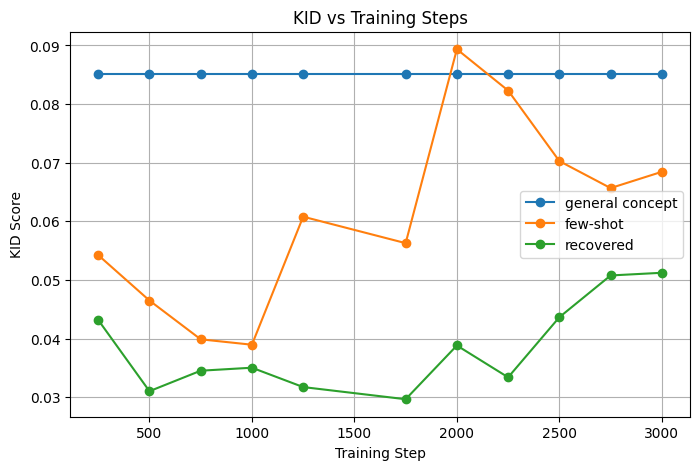

[[0.08516397157157139,
  0.08516397157157139,
  0.08516397157157139,
  0.08516397157157139,
  0.08516397157157139,
  0.08516397157157139,
  0.08516397157157139,
  0.08516397157157139,
  0.08516397157157139,
  0.08516397157157139,
  0.08516397157157139],
 [0.05423232173173187,
  0.04648219919669679,
  0.03986267595845856,
  0.038939589964964993,
  0.06078642156156165,
  0.0562719322622623,
  0.08936328316566568,
  0.08230981245245247,
  0.07027433012262249,
  0.06566865505255239,
  0.06844488804054068],
 [0.04316620488988993,
  0.031010601093593694,
  0.034505646709209165,
  0.03501724768268261,
  0.03171392373123144,
  0.029640025688188198,
  0.03880837034784792,
  0.03337774634384395,
  0.043633699401902044,
  0.050758218711211264,
  0.05121582560560544]]

In [22]:
# data_root/generated/hippo
gen_img_paths = [
    "data_root/generated/hippo",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/generated/Moodeng/A photo of moodeng"
steps = [250, 500, 750, 1000, 1250, 1750, 2000, 2250, 2500, 2750, 3000]
labels = ["general concept","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels)

compute KID between two folders
Found 1000 images in the folder data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-250/A photo of a v1


KID A photo of a v1 : 100%|███████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.27it/s]


Found 1000 images in the folder data_root/generated/Moodeng/A photo of moodeng


KID A photo of moodeng : 100%|████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.25it/s]


data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 250 - KID score: 0.049210398010510456
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1


...

data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1250 - KID score: 0.031713863666166374
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1


KID A photo of a v1 : 100%|███████████████████████████████████████████████████| 32/32 [00:23<00:00,  1.39it/s]


Found 1000 images in the folder data_root/generated/Moodeng/A photo of moodeng


KID A photo of moodeng : 100%|████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.15it/s]


data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1 | Step 1500 - KID score: 0.025349735462963117


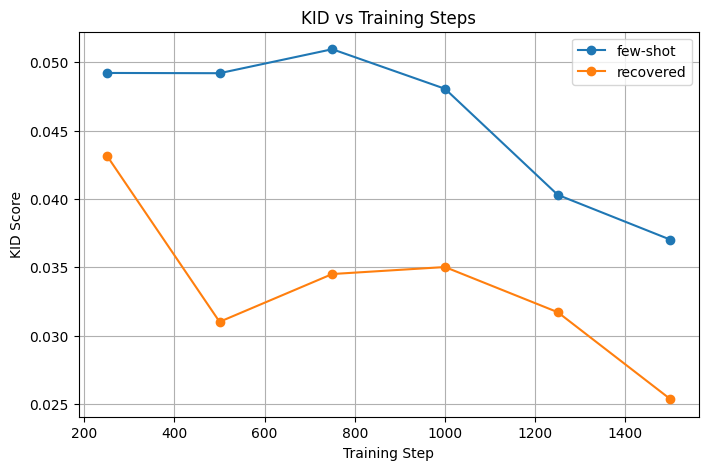

[[0.049210398010510456,
  0.049191978118118325,
  0.05094609918418422,
  0.048051597705205354,
  0.04029519610610632,
  0.03701566341341352],
 [0.043166244917417426,
  0.031010498511011113,
  0.03450566665415411,
  0.035017187645145074,
  0.031713863666166374,
  0.025349735462963117]]

In [ ]:
gen_img_paths = [
    "data_root/generated/hippo",
    "data_root/generated/model/c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1",
    "data_root/generated/model/uul_moodeng.object_c.l4.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
]
ref_img_path = "data_root/generated/Moodeng/A photo of moodeng"
steps = [250, 500, 750, 1000, 1250, 1500]
labels = ["general concept","few-shot","recovered"]

compute_kid_score_multi(gen_img_paths, ref_img_path, steps, labels)

In [9]:
import matplotlib.pyplot as plt
import torch
from cleanfid import fid
def plot_kid_vs_steps(steps, scores, title="KID vs Training Steps", save_path=None):
    """
    Plots KID scores against training steps.

    Args:
        steps (list): List of training steps.
        scores (list): Corresponding KID scores.
        title (str): Title of the plot.
        save_path (str, optional): If provided, saves the plot to this path.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(steps, scores, marker='o', linestyle='-')
    plt.xlabel("Training Step")
    plt.ylabel("KID Score")
    plt.title(title)
    plt.grid(True)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

compute KID between two folders
Found 1000 images in the folder data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-250/A photo of a v1


KID A photo of a v1 : 100%|███████████████████████████████████████████████████| 32/32 [00:13<00:00,  2.30it/s]


Found 1000 images in the folder data_root/generated/Moodeng/A photo of moodeng


KID A photo of moodeng : 100%|████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.16it/s]


KID score: 0.04762542856106097
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1


...

KID score: 0.03280568979229233
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1


KID A photo of a v1 : 100%|███████████████████████████████████████████████████| 32/32 [00:24<00:00,  1.29it/s]


Found 1000 images in the folder data_root/generated/Moodeng/A photo of moodeng


KID A photo of moodeng : 100%|████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.18it/s]


KID score: 0.031344998375875635


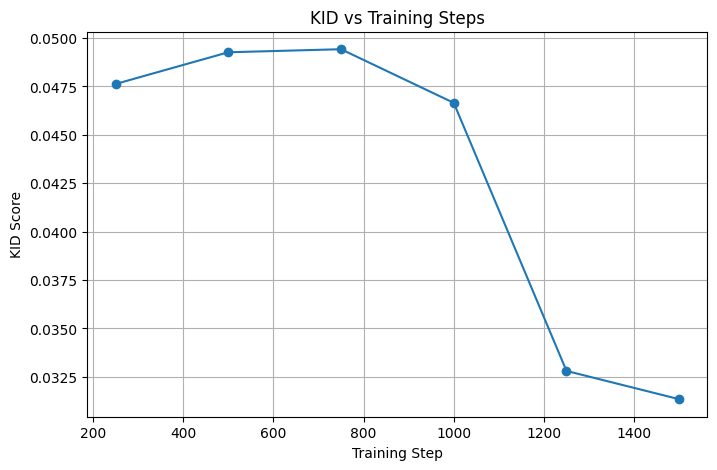

In [7]:



gen_img_path = "data_root/generated/model/c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
ref_img_path = "data_root/generated/Moodeng/A photo of moodeng"


steps = [250,500,750,1000,1250,1500]

scores = []
for step in steps:
    if "{}" in gen_img_path:
        eff_gen_img_path = gen_img_path.format(step)
    else: eff_gen_img_path = gen_img_path

    score = fid.compute_kid(eff_gen_img_path, ref_img_path)
    print(f'KID score: {score}')
    
    scores += [score]

# draw graph steps-KID
plot_kid_vs_steps(steps, scores)



compute KID between two folders
Found 1000 images in the folder data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-250/A photo of a v1


KID A photo of a v1 : 100%|███████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.36it/s]


Found 1000 images in the folder data_root/generated/Moodeng/A photo of moodeng


KID A photo of moodeng : 100%|████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.21it/s]


KID score: 0.039988382077076945
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-500/A photo of a v1


...

KID score: 0.029217521351351604
compute KID between two folders
Found 1000 images in the folder data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-1500/A photo of a v1


KID A photo of a v1 : 100%|███████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.25it/s]


Found 1000 images in the folder data_root/generated/Moodeng/A photo of moodeng


KID A photo of moodeng : 100%|████████████████████████████████████████████████| 32/32 [00:07<00:00,  4.22it/s]


KID score: 0.030563480700700498


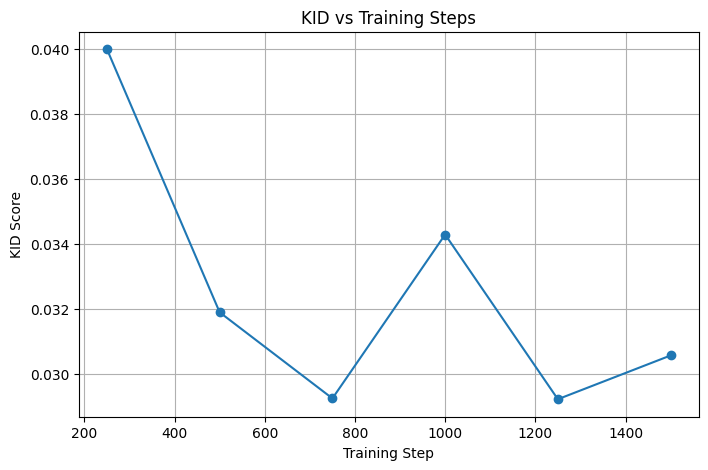

In [8]:



gen_img_path = "data_root/generated/model/uul_moodeng.object_c.l1.kv_moodengU3-V_f0.5_lr.ti1e-2.l5e-5_b1g4/checkpoint-{}/A photo of a v1"
ref_img_path = "data_root/generated/Moodeng/A photo of moodeng"


steps = [250,500,750,1000,1250,1500]

scores = []
for step in steps:
    if "{}" in gen_img_path:
        eff_gen_img_path = gen_img_path.format(step)
    else: eff_gen_img_path = gen_img_path

    score = fid.compute_kid(eff_gen_img_path, ref_img_path)
    print(f'KID score: {score}')
    
    scores += [score]

# draw graph steps-KID
plot_kid_vs_steps(steps, scores)

